# IST3134-BIG-DATA-ANALYTICS-IN-THE-CLOUD

---


## Group Assignment — NYC Yellow Taxi: AWS Spark vs Python


---


Comparing AWS Big Data platform (S3 + EMR/Spark) against a local Python (pandas + scikit-learn) pipeline on the same NYC Yellow Taxi dataset (Oct-Dec 2025- Jan–Mar 2026), across runtime, memory, and model accuracy.

## Problem Statement

---


How do fare amounts, trip duration, and demand vary across NYC pickup zones and time of day, and can we predict trip fare from ride characteristics at scale? We compare an AWS Spark (EMR) implementation against an equivalent local Python implementation to demonstrate the practical advantages/tradeoffs of Big Data Analytics platforms.

# DATASET OVERVIEW



*   Source: [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)
*   Files used: `yellow_tripdata_2026-01.parquet`, `yellow_tripdata_2026-02.parquet`, `yellow_tripdata_2026-03.parquet`, `yellow_tripdata_2025-10.parquet`,`yellow_tripdata_2025-11.parquet`,`yellow_tripdata_2025-12.parquet``taxi_zone_lookup.csv`
*   Size: ~24M rows combined, 391.81MB compressed / ~4.09GB in-memory





In [2]:
import os
import pyarrow.parquet as pq
import pandas as pd

def analyze_parquet(filepath):
    # 1. Raw file size on disk (compressed, what you see in File Explorer)
    file_size_bytes = os.path.getsize(filepath)
    file_size_mb = file_size_bytes / (1024 ** 2)

    # 2. Read metadata without loading full data (fast, low memory)
    parquet_file = pq.ParquetFile(filepath)
    num_rows = parquet_file.metadata.num_rows
    num_columns = parquet_file.metadata.num_columns

    # 3. Load into pandas to get TRUE uncompressed in-memory size
    df = pd.read_parquet(filepath)
    memory_bytes = df.memory_usage(deep=True).sum()
    memory_mb = memory_bytes / (1024 ** 2)

    print(f"File: {os.path.basename(filepath)}")
    print(f"  Compressed file size on disk : {file_size_mb:,.2f} MB")
    print(f"  Number of rows                : {num_rows:,}")
    print(f"  Number of columns             : {num_columns}")
    print(f"  Actual in-memory size (pandas): {memory_mb:,.2f} MB")
    print(f"  Compression ratio             : {memory_mb / file_size_mb:.1f}x")
    print("-" * 50)

    return {
        "file": os.path.basename(filepath),
        "file_size_mb": file_size_mb,
        "num_rows": num_rows,
        "num_columns": num_columns,
        "memory_mb": memory_mb,
    }

# Run across your Jan-Mar files
files = [
    "/content/yellow_tripdata_2026-01.parquet",
    "/content/yellow_tripdata_2026-02.parquet",
    "/content/yellow_tripdata_2026-03.parquet",
    "/content/yellow_tripdata_2025-10.parquet",
    "/content/yellow_tripdata_2025-11.parquet",
    "/content/yellow_tripdata_2025-12.parquet"
]

results = [analyze_parquet(f) for f in files]

# Summary totals — this is the number to put in your proposal
total_file_mb = sum(r["file_size_mb"] for r in results)
total_memory_mb = sum(r["memory_mb"] for r in results)
total_rows = sum(r["num_rows"] for r in results)

print("\n=== TOTAL ACROSS 3 MONTHS ===")
print(f"Total compressed size : {total_file_mb:,.2f} MB ({total_file_mb/1024:.2f} GB)")
print(f"Total in-memory size  : {total_memory_mb:,.2f} MB ({total_memory_mb/1024:.2f} GB)")
print(f"Total rows            : {total_rows:,}")

print("\n=== DETAILED RESULTS (DataFrame) ===")
results_df = pd.DataFrame(results)
display(results_df)

File: yellow_tripdata_2026-01.parquet
  Compressed file size on disk : 61.19 MB
  Number of rows                : 3,724,889
  Number of columns             : 20
  Actual in-memory size (pandas): 647.96 MB
  Compression ratio             : 10.6x
--------------------------------------------------
File: yellow_tripdata_2026-02.parquet
  Compressed file size on disk : 55.96 MB
  Number of rows                : 3,399,866
  Number of columns             : 20
  Actual in-memory size (pandas): 590.68 MB
  Compression ratio             : 10.6x
--------------------------------------------------
File: yellow_tripdata_2026-03.parquet
  Compressed file size on disk : 64.75 MB
  Number of rows                : 3,952,451
  Number of columns             : 20
  Actual in-memory size (pandas): 692.73 MB
  Compression ratio             : 10.7x
--------------------------------------------------
File: yellow_tripdata_2025-10.parquet
  Compressed file size on disk : 71.78 MB
  Number of rows                

,file,file_size_mb,num_rows,num_columns,memory_mb
0,yellow_tripdata_2026-01.parquet,61.192589,3724889,20,647.964033
1,yellow_tripdata_2026-02.parquet,55.964807,3399866,20,590.675764
2,yellow_tripdata_2026-03.parquet,64.746140,3952451,20,692.726492
3,yellow_tripdata_2025-10.parquet,71.780766,4428699,20,777.902489
4,yellow_tripdata_2025-11.parquet,67.838912,4181444,20,732.508900
5,yellow_tripdata_2025-12.parquet,70.287063,4305006,20,750.416508



# Python (pandas + scikit-learn) Pipeline - NYC Yellow Taxi Trip Analysis

Runs locally.
Mirrors the AWS Spark pipeline exactly (same filters, same aggregations, same model features) so the two are a fair comparison.

Stages:
  1. Load Parquet files
  2. Clean / filter invalid records
  3. Join with taxi zone lookup table
  4. Aggregate: fare/demand patterns by zone, hour, day-of-week
  5. Train scikit-learn regression model to predict fare_amount
  6. Log timing + memory for every stage -> metrics_python.json





In [3]:
import argparse
import glob
import gc
import json
import os
import time
import tracemalloc
from contextlib import contextmanager

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Copy-on-Write mode (pandas >= 2.0): filtering/selecting a DataFrame no
# longer silently makes hidden extra copies, and later column assignments
# on a filtered frame (e.g. df_clean["x"] = ...) work correctly without
# needing an explicit .copy(). This is the main lever that lets us drop
# the .copy() calls later in the pipeline safely.
pd.options.mode.copy_on_write = True


# Timing + memory helper

In [4]:
timings = {}
peak_memory = {}


@contextmanager
def timed_stage(name):
    print(f"\n[START] {name}")
    tracemalloc.start()
    t0 = time.time()
    yield
    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    timings[name] = round(elapsed, 3)
    peak_memory[name] = round(peak / (1024 ** 2), 2)  # MB
    print(f"[DONE]  {name} - {elapsed:.2f}s | peak memory: {peak_memory[name]} MB")


def main(input_dir, zones_path, output_dir):
    overall_start = time.time()
    os.makedirs(output_dir, exist_ok=True)

# Stage 1: Load data

In [5]:
input_dir = "/content/"
zones_path = "/content/taxi_zone_lookup.csv"

# Only load the columns actually used anywhere downstream. The raw files
# have 20 columns; we only need 10 of them. This alone roughly halves
# memory before any cleaning even happens.
NEEDED_COLS = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "fare_amount", "trip_distance", "passenger_count",
    "PULocationID", "DOLocationID",
    "payment_type", "tip_amount", "total_amount",
]

def load_and_shrink(path, cols):
    """Read only the needed columns and downcast the float64 columns to
    float32 immediately, per file, instead of loading everything at
    float64 and downcasting later (which would need 2x the RAM at once)."""
    d = pd.read_parquet(path, columns=cols)
    for c in ["fare_amount", "trip_distance", "tip_amount",
              "total_amount", "passenger_count", "payment_type"]:
        d[c] = d[c].astype("float32")
    return d

with timed_stage("load_data"):
    files = sorted(glob.glob(os.path.join(input_dir, "*.parquet")))
    print(f"Loading {len(files)} file(s): {files}")

    # Load + shrink one file at a time and concat the already-small
    # frames, rather than concatenating the raw (20-col, float64) frames
    # first and shrinking afterwards.
    chunks = [load_and_shrink(f, NEEDED_COLS) for f in files]
    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()

    zones = pd.read_csv(zones_path)
    row_count_raw = len(df)
    print(f"Raw row count: {row_count_raw:,}")
    print(f"Raw in-memory size: {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")



[START] load_data
Loading 6 file(s): ['/content/yellow_tripdata_2025-10.parquet', '/content/yellow_tripdata_2025-11.parquet', '/content/yellow_tripdata_2025-12.parquet', '/content/yellow_tripdata_2026-01.parquet', '/content/yellow_tripdata_2026-02.parquet', '/content/yellow_tripdata_2026-03.parquet']
Raw row count: 23,992,355
Raw in-memory size: 1,098.3 MB
[DONE]  load_data - 6.68s | peak memory: 1647.55 MB


# Stage 2: Cleaning

In [6]:
# 1. Create trip duration min (Feature Engineering)
with timed_stage("cleaning"):
    df["trip_duration_min"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60.0

# 2. Remove invalid records (Data Cleaning)
    mask = (
        (df["fare_amount"] > 0)
        & (df["trip_distance"] > 0)
        & (df["passenger_count"] > 0)
        & (df["trip_duration_min"] > 0.5)
        & (df["trip_duration_min"] < 180)
        & (df["PULocationID"].notna())
        & (df["DOLocationID"].notna())
    )

# 3. Create cleaned dataset
    '''df[mask] (boolean indexing) already returns a brand-new copy on its
    own - the extra .copy() in the original code made pandas allocate
    the ~24M-row filtered frame TWICE before the first one could be
    garbage collected, which is what caused the crash. Just reassigning
    (no .copy()) avoids that duplicate allocation.'''
    df_clean = df[mask]

# 4. Descriptive statistics
    # Display descriptive statistics for df_clean immediately after creation
    print("\nDescriptive statistics for df_clean (after initial filtering):\n")
    print(f"Shape of df_clean: {df_clean.shape}")
    display(df_clean.describe())
    display(df_clean.info())
    display(df_clean.head())

    print(f"Minimum fare_amount in df_clean: {df_clean['fare_amount'].min():.2f}")
    print(f"Maximum fare_amount in df_clean: {df_clean['fare_amount'].max():.2f}\n")

# 5. Memory optimization
    '''We no longer need the raw, full-width frame - drop the reference
    and force garbage collection so its memory is actually released
    before we add more columns below.'''
    del df, mask
    gc.collect()

    # Safe to downcast location IDs now that notna() has already been
    # enforced by the mask above (int dtypes can't hold NaN).
    df_clean["PULocationID"] = df_clean["PULocationID"].astype("int16")
    df_clean["DOLocationID"] = df_clean["DOLocationID"].astype("int16")

# 6. Create pickup hour (Feature Engineering)
    df_clean["pickup_hour"] = df_clean["tpep_pickup_datetime"].dt.hour.astype("int8")
# 7. Create pickup day (Feature Engineering)
    df_clean["pickup_dow"] = df_clean["tpep_pickup_datetime"].dt.day_name().astype("category")

    row_count_clean = len(df_clean)
    print(f"Clean row count: {row_count_clean:,} "
          f"({row_count_raw - row_count_clean:,} rows removed)")
    print(f"df_clean in-memory size: {df_clean.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")

# 8. Create ML dataset
    '''Pull out the small ML feature set NOW, while df_clean still has
    everything. This becomes its own tiny 5-column frame, so the ML
    stage later never needs to touch the big row-level table again -
    it can be freed after the aggregation stages are done with it.'''
    ml_df = df_clean[
        ["fare_amount", "trip_distance", "passenger_count", "pickup_hour", "PULocationID"]
    ].dropna().copy()
    print(f"ml_df in-memory size: {ml_df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")


[START] cleaning

Descriptive statistics for df_clean (after initial filtering):

Shape of df_clean: (16803729, 11)


,tpep_pickup_datetime,tpep_dropoff_datetime,fare_amount,trip_distance,passenger_count,PULocationID,DOLocationID,payment_type,tip_amount,total_amount,trip_duration_min
count,16803729,16803729,1.680373e+07,1.680373e+07,1.680373e+07,1.680373e+07,1.680373e+07,1.680373e+07,1.680373e+07,1.680373e+07,1.680373e+07
mean,2025-12-27 06:28:38.637062,2025-12-27 06:46:36.787932,2.000585e+01,3.492121e+00,1.271686e+00,1.652031e+02,1.648482e+02,1.152799e+00,3.702445e+00,2.966127e+01,1.796918e+01
min,2008-12-31 23:04:21,2008-12-31 23:32:25,1.000000e-02,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,7.000000e-01,5.166667e-01
25%,2025-11-10 11:53:31,2025-11-10 12:11:48,9.300000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,1.000000e+00,1.680000e+01,7.966667e+00
50%,2025-12-20 23:11:12,2025-12-20 23:28:43,1.350000e+01,1.700000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,3.000000e+00,2.205000e+01,1.328333e+01
75%,2026-02-12 12:51:15,2026-02-12 13:11:45,2.260000e+01,3.390000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,4.630000e+00,3.205000e+01,2.218333e+01
max,2026-04-01 00:06:25,2026-04-01 01:22:42,1.245500e+03,1.869676e+05,9.000000e+00,2.650000e+02,2.650000e+02,4.000000e+00,7.660000e+02,1.261310e+03,1.799833e+02
std,NaN,NaN,1.756374e+01,6.125843e+01,6.924950e-01,6.348440e+01,6.949095e+01,4.562606e-01,4.035813e+00,2.221173e+01,1.571694e+01


<class 'pandas.core.frame.DataFrame'>
Index: 16803729 entries, 0 to 23046606
Data columns (total 11 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   fare_amount            float32       
 3   trip_distance          float32       
 4   passenger_count        float32       
 5   PULocationID           int32         
 6   DOLocationID           int32         
 7   payment_type           float32       
 8   tip_amount             float32       
 9   total_amount           float32       
 10  trip_duration_min      float64       
dtypes: datetime64[us](2), float32(6), float64(1), int32(2)
memory usage: 1.0 GB


None

,tpep_pickup_datetime,tpep_dropoff_datetime,fare_amount,trip_distance,passenger_count,PULocationID,DOLocationID,payment_type,tip_amount,total_amount,trip_duration_min
0,2025-10-01 00:15:32,2025-10-01 01:04:03,70.0,17.200001,1.0,132,107,1.0,0.00,83.440002,48.516667
2,2025-10-01 00:08:54,2025-10-01 00:14:44,12.8,2.750000,1.0,263,229,1.0,3.71,22.260000,5.833333
3,2025-10-01 00:58:48,2025-10-01 01:04:40,7.9,1.300000,1.0,211,231,2.0,0.00,13.650000,5.866667
4,2025-10-01 00:39:51,2025-10-01 00:49:40,14.2,2.880000,1.0,230,151,1.0,3.99,23.940001,9.816667
5,2025-10-01 00:30:54,2025-10-01 00:37:50,9.3,1.600000,1.0,237,142,2.0,0.00,14.300000,6.933333


Minimum fare_amount in df_clean: 0.01
Maximum fare_amount in df_clean: 1245.50

Clean row count: 16,803,729 (7,188,626 rows removed)
df_clean in-memory size: 993.6 MB
ml_df in-memory size: 368.6 MB
[DONE]  cleaning - 70.57s | peak memory: 2551.54 MB


# Stage 3: Join with zone lookup

In [7]:
with timed_stage("join_zones"):
    zones_renamed = zones.rename(
        columns={"LocationID": "PULocationID", "Borough": "PU_Borough", "Zone": "PU_Zone"}
    )[["PULocationID", "PU_Borough", "PU_Zone"]]

    '''Reassign the merge result back onto df_clean instead of creating a
    new df_joined variable. This keeps only ONE big frame alive at a
    time - the pre-merge version of df_clean is garbage collected as
    soon as merge() returns, since ml_df (extracted above) is the only
    other thing that still needs the pre-join data.'''
    df_clean = df_clean.merge(zones_renamed, on="PULocationID", how="left")
    df_clean["PU_Borough"] = df_clean["PU_Borough"].astype("category")
    df_clean["PU_Zone"] = df_clean["PU_Zone"].astype("category")
    gc.collect()



[START] join_zones
[DONE]  join_zones - 3.73s | peak memory: 929.49 MB


# Stage 4: Aggregations

In [8]:
output_dir = "/content/output/"
os.makedirs(output_dir, exist_ok=True)

with timed_stage("aggregation_zone_hour"):
    agg_zone_hour = (
        df_clean.groupby(["PU_Borough", "PU_Zone", "pickup_hour"], observed=True)
        .agg(
            trip_count=("fare_amount", "count"),
            avg_fare=("fare_amount", "mean"),
            avg_distance=("trip_distance", "mean"),
            avg_duration_min=("trip_duration_min", "mean"),
        )
        .round(2)
        .sort_values("trip_count", ascending=False)
        .reset_index()
    )
    agg_zone_hour.to_parquet(os.path.join(output_dir, "agg_zone_hour.parquet"))

with timed_stage("aggregation_day_of_week"):
    df_clean["tip_pct"] = df_clean["tip_amount"] / df_clean["fare_amount"] * 100
    agg_dow = (
        df_clean.groupby("pickup_dow", observed=True)
        .agg(
            trip_count=("fare_amount", "count"),
            total_revenue=("total_amount", "sum"),
            avg_tip_pct=("tip_pct", "mean"),
        )
        .round(2)
        .sort_values("trip_count", ascending=False)
        .reset_index()
    )
    agg_dow.to_parquet(os.path.join(output_dir, "agg_day_of_week.parquet"))



[START] aggregation_zone_hour
[DONE]  aggregation_zone_hour - 1.49s | peak memory: 689.12 MB

[START] aggregation_day_of_week
[DONE]  aggregation_day_of_week - 0.88s | peak memory: 256.43 MB


## Stage 4b: Aggregation - Payment Type Analysis

In [9]:
payment_map = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided Trip",
}

with timed_stage("aggregation_payment_type"):
    df_clean["payment_type_label"] = df_clean["payment_type"].map(payment_map).fillna("Unknown")

    agg_payment = (
        df_clean.groupby("payment_type_label", observed=True)
        .agg(
            trip_count=("fare_amount", "count"),
            avg_fare=("fare_amount", "mean"),
            avg_tip_pct=("tip_pct", "mean"),
            total_revenue=("total_amount", "sum"),
        )
        .round(2)
        .sort_values("trip_count", ascending=False)
        .reset_index()
    )
    agg_payment["pct_of_trips"] = (
        agg_payment["trip_count"] / agg_payment["trip_count"].sum() * 100
    ).round(2)

    agg_payment.to_parquet(os.path.join(output_dir, "agg_payment_type.parquet"))

print(agg_payment)



[START] aggregation_payment_type
[DONE]  aggregation_payment_type - 4.82s | peak memory: 817.3 MB
  payment_type_label  trip_count  avg_fare  avg_tip_pct  total_revenue  \
0        Credit Card    14633851     19.98        24.85    442103904.0   
1               Cash     1943034     19.85         0.00     49696168.0   
2            Dispute      170865     23.91         0.01      5160717.0   
3          No Charge       55979     20.15         0.01      1459282.5   

   pct_of_trips  
0         87.09  
1         11.56  
2          1.02  
3          0.33  


## Stage 4c: Aggregation - Borough-to-Borough Flow (Origin-Destination)

In [10]:
with timed_stage("join_do_zone"):
    zones_do_renamed = zones.rename(
        columns={"LocationID": "DOLocationID", "Borough": "DO_Borough", "Zone": "DO_Zone"}
    )[["DOLocationID", "DO_Borough", "DO_Zone"]]

    # Same pattern as Stage 3: merge back onto df_clean in place instead
    # of creating a separate df_flow variable, so we never hold both the
    # pre- and post-merge full frames (plus df_joined) alive together.
    df_clean = df_clean.merge(zones_do_renamed, on="DOLocationID", how="left")
    df_clean["DO_Borough"] = df_clean["DO_Borough"].astype("category")
    gc.collect()

with timed_stage("aggregation_borough_flow"):
    agg_borough_flow = (
        df_clean.groupby(["PU_Borough", "DO_Borough"], observed=True)
        .agg(
            trip_count=("fare_amount", "count"),
            avg_fare=("fare_amount", "mean"),
            avg_distance=("trip_distance", "mean"),
        )
        .round(2)
        .sort_values("trip_count", ascending=False)
        .reset_index()
    )
    agg_borough_flow.to_parquet(os.path.join(output_dir, "agg_borough_flow.parquet"))

print(agg_borough_flow.head(15))

# All aggregations are saved to disk - the big row-level frame has done
# its job. Free it now; the ML stage only needs the small ml_df that was
# extracted back in Stage 2, before any of these joins happened.
del df_clean, zones_renamed, zones_do_renamed
gc.collect()



[START] join_do_zone
[DONE]  join_do_zone - 2.87s | peak memory: 929.49 MB

[START] aggregation_borough_flow
[DONE]  aggregation_borough_flow - 1.29s | peak memory: 544.88 MB
   PU_Borough DO_Borough  trip_count   avg_fare  avg_distance
0   Manhattan  Manhattan    13753042  13.840000          1.84
1      Queens  Manhattan      940542  57.509998         13.78
2   Manhattan     Queens      410055  48.110001         11.15
3   Manhattan   Brooklyn      368620  33.549999          6.86
4      Queens     Queens      334061  35.150002          7.51
5      Queens   Brooklyn      286211  55.119999         13.14
6    Brooklyn   Brooklyn      149993  22.639999          3.88
7   Manhattan      Bronx       92934  35.930000          9.00
8    Brooklyn  Manhattan       85107  37.830002          9.24
9       Bronx  Manhattan       68919  33.980000          8.57
10   Brooklyn     Queens       45398  40.419998         10.70
11     Queens      Bronx       39121  58.910000         15.46
12  Manhattan     

0


# Stage 5: ML - predict fare_amount (scikit-learn)


In [11]:
with timed_stage("ml_training"):
    X = ml_df[["trip_distance", "passenger_count", "pickup_hour", "PULocationID"]]
    y = ml_df["fare_amount"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("zone_ohe", OneHotEncoder(handle_unknown="ignore"), ["PULocationID"]),
        ],
        remainder="passthrough",
    )

    model_pipeline = Pipeline(
        steps=[("preprocess", preprocessor), ("regressor", LinearRegression())]
    )

    model_pipeline.fit(X_train, y_train)

with timed_stage("ml_evaluation"):
    y_pred = model_pipeline.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2 = float(r2_score(y_test, y_pred))
    print(f"scikit-learn -> RMSE: {rmse:.3f}, R2: {r2:.3f}")

# Done with the training data itself - keep only y_test/y_pred, which the
# later "Actual vs Predicted" chart cell needs.
del ml_df, X, X_train, X_test, y, y_train
gc.collect()



[START] ml_training
[DONE]  ml_training - 54.62s | peak memory: 2334.21 MB

[START] ml_evaluation
scikit-learn -> RMSE: 13.457, R2: 0.451
[DONE]  ml_evaluation - 1.19s | peak memory: 459.34 MB


46

# Convert to CSV + Chart

=== PYTHON PIPELINE METRICS ===
                                       metric                          value
                                     platform Python (pandas + scikit-learn)
                                raw_row_count                       23992355
                              clean_row_count                       16803729
                               total_time_sec                        148.148
                                   model_rmse                         13.457
                                     model_r2                          0.451
                     stage_load_data_time_sec                          6.683
                      stage_cleaning_time_sec                         70.568
                    stage_join_zones_time_sec                          3.735
         stage_aggregation_zone_hour_time_sec                          1.486
       stage_aggregation_day_of_week_time_sec                          0.884
      stage_aggregation_payment_type_time_se

/tmp/ipykernel_1364/4010746829.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_zone_hour.groupby("PU_Zone")["trip_count"]


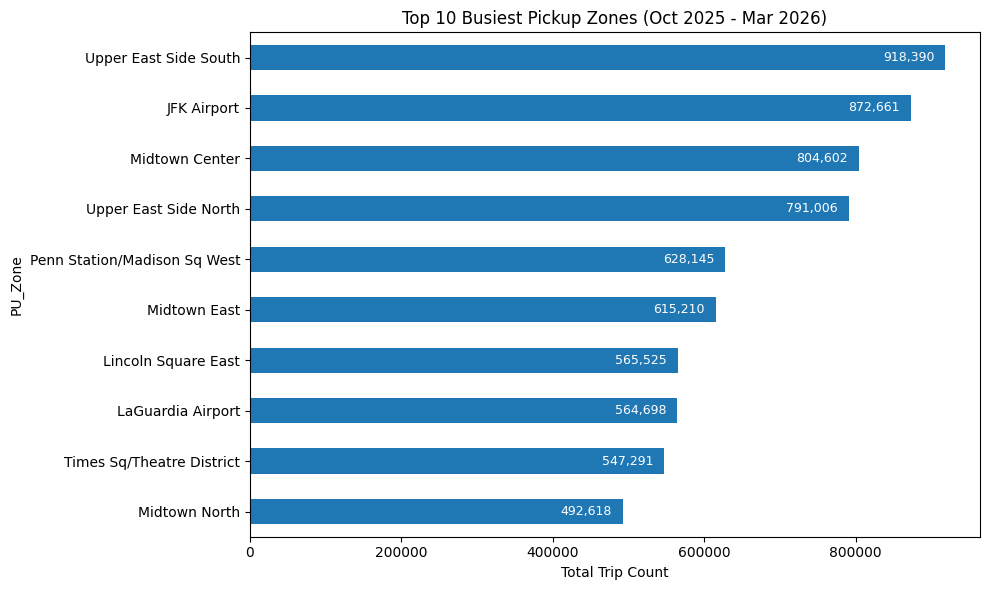

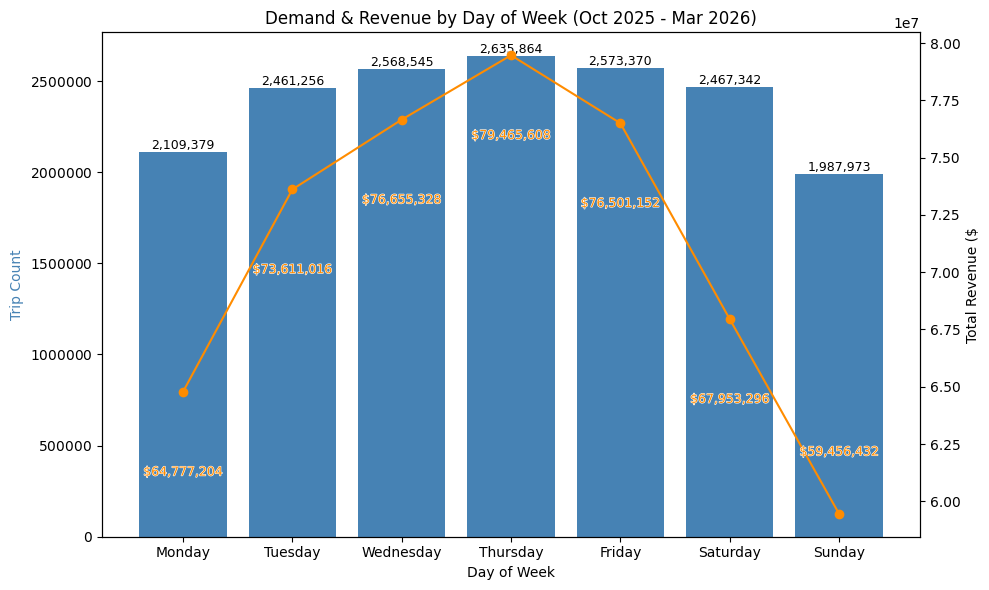

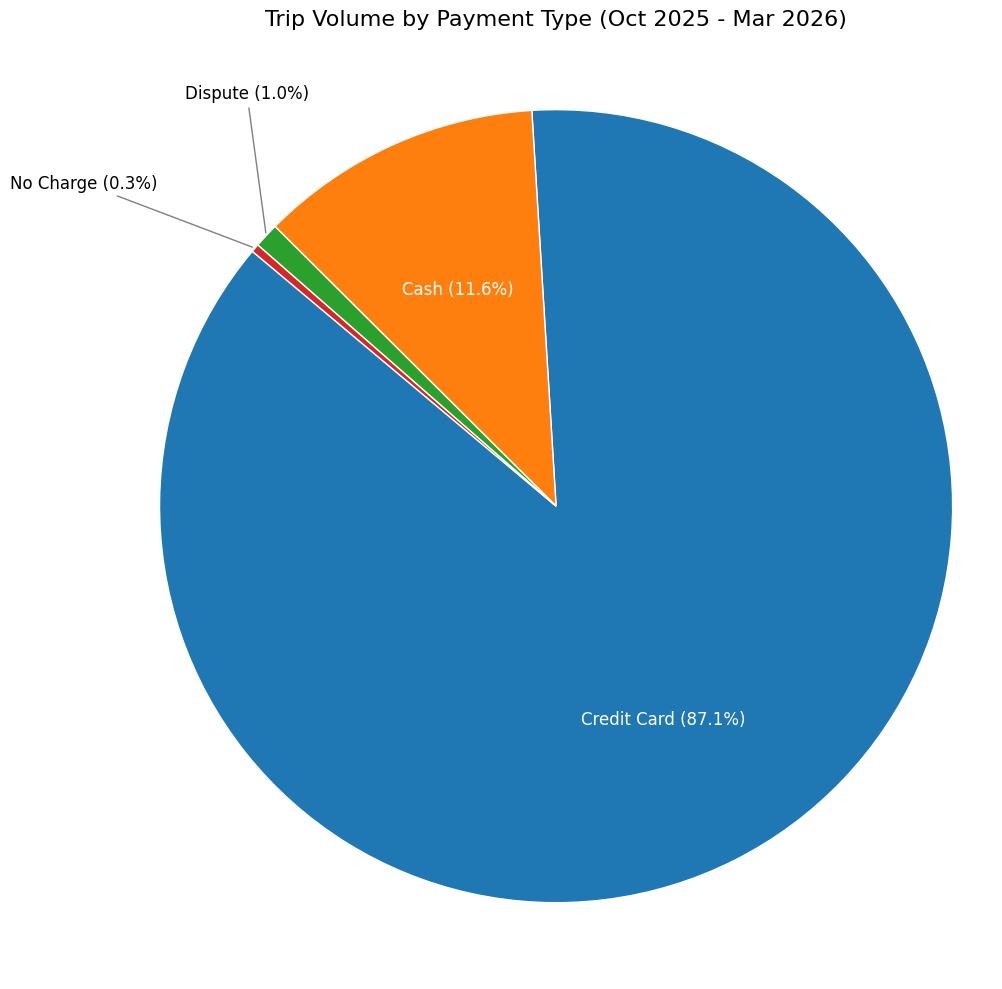

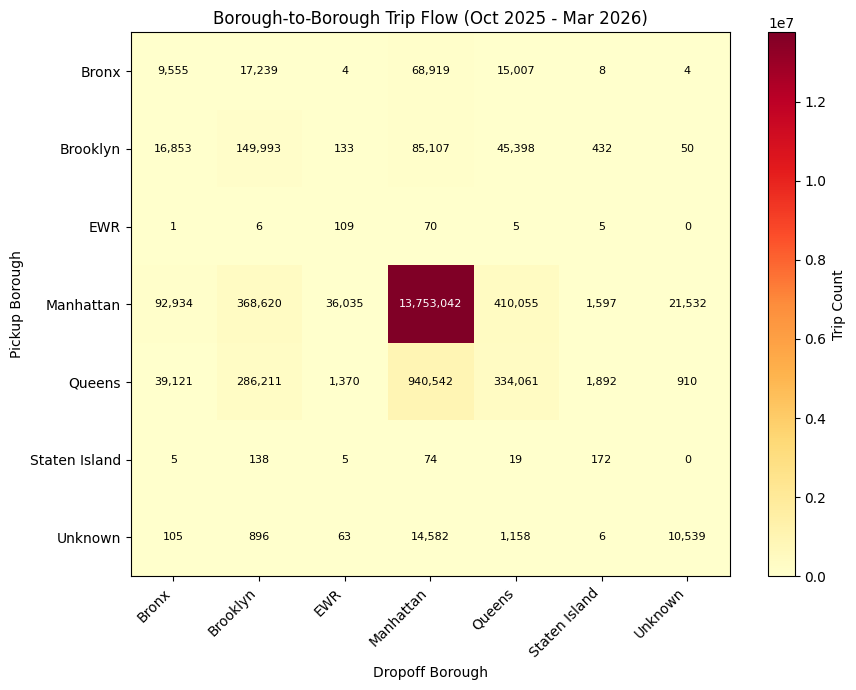


Done. CSV + JSON saved to output_dir. Charts shown above.


In [12]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np # Import numpy for mathematical operations
from matplotlib.patheffects import withStroke # Import for text outline

# 0. Output directory - everything gets saved here
output_dir = "/content/output/"
os.makedirs(output_dir, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Build + save metrics (assumes `timings`, `peak_memory`, `row_count_raw`,
#    `row_count_clean`, `rmse`, `r2` already exist from earlier pipeline cells)
# ---------------------------------------------------------------------
total_time = sum(timings.values())
metrics = {
    "platform": "Python (pandas + scikit-learn)",
    "raw_row_count": int(row_count_raw),
    "clean_row_count": int(row_count_clean),
    "total_time_sec": round(total_time, 3),
    "model_rmse": round(rmse, 3),
    "model_r2": round(r2, 3),
}

# Flatten stage_timings_sec and stage_peak_memory_mb into metrics dictionary
for stage, value in timings.items():
    metrics[f"stage_{stage}_time_sec"] = round(value, 3)
for stage, value in peak_memory.items():
    metrics[f"stage_{stage}_peak_memory_mb"] = round(value, 2)

metrics_df = pd.DataFrame(list(metrics.items()), columns=['metric', 'value'])
metrics_csv_path = os.path.join(output_dir, "metrics_python.csv")
metrics_df.to_csv(metrics_csv_path, index=False)

print("=== PYTHON PIPELINE METRICS ===")
print(metrics_df.to_string(index=False))
print(f"\nSaved: {metrics_csv_path}")

# ---------------------------------------------------------------------
# 2. Load the two aggregation outputs
# ---------------------------------------------------------------------
agg_zone_hour = pd.read_parquet(os.path.join(output_dir, "agg_zone_hour.parquet"))
agg_dow = pd.read_parquet(os.path.join(output_dir, "agg_day_of_week.parquet"))
agg_payment = pd.read_parquet(os.path.join(output_dir, "agg_payment_type.parquet"))
agg_borough_flow = pd.read_parquet(os.path.join(output_dir, "agg_borough_flow.parquet"))

print(f"\nagg_zone_hour.parquet -> {len(agg_zone_hour):,} rows")
print(agg_zone_hour.head(10))

print(f"\nagg_day_of_week.parquet -> {len(agg_dow):,} rows")
print(agg_dow)

print(f"\nagg_payment_type.parquet -> {len(agg_payment):,} rows")
print(agg_payment)

print(f"\nagg_borough_flow.parquet -> {len(agg_borough_flow):,} rows")
print(agg_borough_flow.head(15))

# ---------------------------------------------------------------------
# 3. Convert to CSV, saved into output_dir
# ---------------------------------------------------------------------
zone_hour_csv = os.path.join(output_dir, "agg_zone_hour.csv")
dow_csv = os.path.join(output_dir, "agg_day_of_week.csv")
payment_csv = os.path.join(output_dir, "agg_payment_type.csv")
borough_flow_csv = os.path.join(output_dir, "agg_borough_flow.csv")

agg_zone_hour.to_csv(zone_hour_csv, index=False)
agg_dow.to_csv(dow_csv, index=False)
agg_payment.to_csv(payment_csv, index=False)
agg_borough_flow.to_csv(borough_flow_csv, index=False)
print(f"\nSaved: {zone_hour_csv}")
print(f"Saved: {dow_csv}")
print(f"Saved: {payment_csv}")
print(f"Saved: {borough_flow_csv}")

# ---------------------------------------------------------------------
# 4. Chart 1 - Top 10 busiest zones by trip count (Horizontal Bar Chart)
# ----------------------------------------------------------------------
top_zones = (
    agg_zone_hour.groupby("PU_Zone")["trip_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
ax = top_zones.plot(kind="barh")
plt.xlabel("Total Trip Count")
plt.title("Top 10 Busiest Pickup Zones (Oct 2025 - Mar 2026)")
plt.gca().invert_yaxis()

# Add data labels (moved inside the bars, adjusted position)
for index, value in enumerate(top_zones):
    # Adjust x-position to be more inside the bar. Using get_xlim() maximum for reference
    ax.text(value - (ax.get_xlim()[1] * 0.015), index, f'{value:,.0f}', va='center', ha='right', color='white', fontsize=9)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 5. Chart 2 - Trip demand & revenue by day of week (Bar + Line)
# ---------------------------------------------------------------------
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
agg_dow_sorted = agg_dow.set_index("pickup_dow").reindex(day_order)

fig, ax1 = plt.subplots(figsize=(10, 6))
bars = ax1.bar(agg_dow_sorted.index, agg_dow_sorted["trip_count"], color="steelblue", label="Trip Count")
ax1.set_ylabel("Trip Count", color="steelblue")
ax1.set_xlabel("Day of Week")

# Fix y-axis label numbering
formatter = ScalarFormatter(useOffset=False, useMathText=True)
formatter.set_scientific(False)
ax1.yaxis.set_major_formatter(formatter)

# Add data labels for trip count bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', va='bottom', ha='center', color='black', fontsize=9)

ax2 = ax1.twinx()
line_plot, = ax2.plot(agg_dow_sorted.index, agg_dow_sorted["total_revenue"], color="darkorange",
         marker="o", label="Total Revenue")
ax2.set_ylabel("Total Revenue ($")

# Add data labels for revenue line
# Apply white outline to darkorange text for better visibility
path_effects = [withStroke(linewidth=0.8, foreground='white')]

for i, (x, y) in enumerate(zip(line_plot.get_xdata(), line_plot.get_ydata())):
    day = agg_dow_sorted.index[i] # Get the day name

    if day == 'Sunday':
        # Place Sunday label above the dot
        offset_y = (ax2.get_ylim()[1] * 0.03) # Positive offset for 'bottom' alignment
        ax2.text(x, y + offset_y, f'${y:,.0f}', va='bottom', ha='center',
                 color='darkorange', fontsize=9, path_effects=path_effects)
    else:
        # Place other labels below the dot
        offset_y = -(ax2.get_ylim()[1] * 0.04) # Negative offset for 'top' alignment
        ax2.text(x, y + offset_y, f'${y:,.0f}', va='top', ha='center',
                 color='darkorange', fontsize=9, path_effects=path_effects)

plt.title("Demand & Revenue by Day of Week (Oct 2025 - Mar 2026)")
fig.tight_layout()
plt.show()



# ---------------------------------------------------------------------
# 6. Chart 3 - Trip volume by payment type (Pie Chart)
# ---------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(10, 10)) # Reduced figure size for better overall fit
labels_data = agg_payment["payment_type_label"]
sizes = agg_payment["trip_count"]
percentages = agg_payment["pct_of_trips"]

# Plot the pie chart without labels or autopct for custom annotation
wedges, _ = ax3.pie(sizes, startangle=140,
                    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
                    radius=0.9)

total_radius = 0.9 # This is the radius used in plt.pie

# Annotate each slice with label and percentage, using arrows
for i, wedge in enumerate(wedges):
    label = labels_data.iloc[i]
    percentage = percentages.iloc[i]
    text = f'{label} ({percentage:.1f}%)'

    # Calculate mid-point of the wedge for positioning
    angle = (wedge.theta2 + wedge.theta1) / 2.0
    # Unit vector components for the angle
    x_unit = np.cos(np.deg2rad(angle))
    y_unit = np.sin(np.deg2rad(angle))

    if label in ["Credit Card", "Cash"]:
        # For Credit Card and Cash, place inside the slice
        # Adjust label_radius to place the text comfortably inside the wedge
        label_radius_inside = total_radius * 0.6
        final_x = label_radius_inside * x_unit
        final_y = label_radius_inside * y_unit
        ax3.annotate(text,
                     xy=(final_x, final_y),
                     ha='center', va='center', color='white', fontsize=12) # Unbolded, color white for visibility
    else: # For 'No Charge' and 'Dispute', keep outside with arrows
        # Start point of the arrow on the arrow_start_x
        arrow_start_x = total_radius * x_unit
        arrow_start_y = total_radius * y_unit

        label_distance_multiplier = 1.2
        adjusted_angle = angle # Default no adjustment
        if label == "No Charge":
            label_distance_multiplier = 1.6 # Push it further out
            adjusted_angle = angle + 10 # Nudge angle slightly to separate from Dispute
        elif label == "Dispute":
            label_distance_multiplier = 1.4 # Push it further out
            adjusted_angle = angle - 5 # Nudge angle slightly

        # End point of the arrow (text position)
        label_x_pos = (total_radius * label_distance_multiplier) * np.cos(np.deg2rad(adjusted_angle))
        label_y_pos = (total_radius * label_distance_multiplier) * np.sin(np.deg2rad(adjusted_angle))

        # Determine horizontal alignment for text
        if angle > 90 and angle < 270:
            ha = 'right'
        else:
            ha = 'left'

        ax3.annotate(text,
                     xy=(arrow_start_x, arrow_start_y),
                     xytext=(label_x_pos, label_y_pos),
                     textcoords='data',
                     arrowprops=dict(arrowstyle='-', connectionstyle='arc3,rad=0', color='gray'),
                     fontsize=12, ha=ha, va='center', color='black')

ax3.set_title("Trip Volume by Payment Type (Oct 2025 - Mar 2026)", fontsize=16)
ax3.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 7. Chart 4 - Borough-to-Borough trip flow heatmap (heatmap-style matrix)
# ---------------------------------------------------------------------
flow_pivot = agg_borough_flow.pivot(
    index="PU_Borough", columns="DO_Borough", values="trip_count"
).fillna(0)

plt.figure(figsize=(9, 7))
plt.imshow(flow_pivot, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="Trip Count")
plt.xticks(range(len(flow_pivot.columns)), flow_pivot.columns, rotation=45, ha="right")
plt.yticks(range(len(flow_pivot.index)), flow_pivot.index)
plt.xlabel("Dropoff Borough")
plt.ylabel("Pickup Borough")
plt.title("Borough-to-Borough Trip Flow (Oct 2025 - Mar 2026)")

vmax = flow_pivot.values.max()
for i in range(flow_pivot.shape[0]):
    for j in range(flow_pivot.shape[1]):
        val = flow_pivot.iloc[i, j]
        plt.text(
            j, i, f"{int(val):,}", ha="center", va="center",
            color="white" if val > vmax / 2 else "black", fontsize=8,
        )
plt.tight_layout()
plt.show()



print("\nDone. CSV + JSON saved to output_dir. Charts shown above.")

/tmp/ipykernel_1364/3551263798.py:54: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


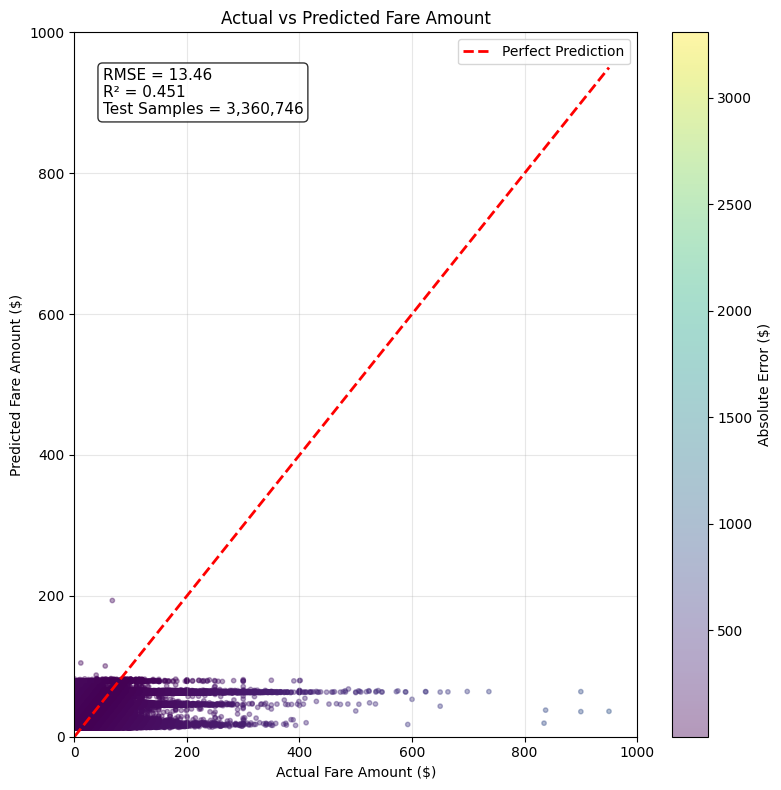

In [13]:
# ---------------------------------------------------------------------
# Chart 5 - Actual vs Predicted Fare (Scatter Plot)
# ---------------------------------------------------------------------

plt.figure(figsize=(8,8))

# Calculate errors for coloring the scatter plot
errors = np.abs(y_test - y_pred)

plt.scatter(
    y_test,
    y_pred,
    c=errors,
    cmap="viridis",
    alpha=0.4,
    s=10
)

plt.colorbar(label="Absolute Error ($)")

# Set x and y axis limits to $1000 maximum
plt.xlim(0, 1000)
plt.ylim(0, 1000)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

textstr = (
    f"RMSE = {rmse:.2f}\n"
    f"R² = {r2:.3f}\n"
    f"Test Samples = {len(y_test):,}"
)

plt.text(
    0.05,
    0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.xlabel("Actual Fare Amount ($)")
plt.ylabel("Predicted Fare Amount ($)")
plt.title("Actual vs Predicted Fare Amount")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Summary Metrics

In [14]:
summary_metrics = {
    'Platform': metrics['platform'],
    'Raw Row Count': metrics['raw_row_count'],
    'Clean Row Count': metrics['clean_row_count'],
    'Total Time (sec)': metrics['total_time_sec'],
    'Model RMSE': metrics['model_rmse'],
    'Model R2': metrics['model_r2']
}
summary_df = pd.DataFrame.from_dict(summary_metrics, orient='index', columns=['Value'])
summary_df.index.name = 'Metric'
display(summary_df)

,Value
Metric,
Platform,Python (pandas + scikit-learn)
Raw Row Count,23992355
Clean Row Count,16803729
Total Time (sec),148.148
Model RMSE,13.457
Model R2,0.451


## Stage Timings (Seconds)

In [17]:
timings_df = pd.DataFrame.from_dict(timings, orient='index', columns=['Time (sec)'])
timings_df.index.name = 'Stage'
display(timings_df)

,Time (sec)
Stage,
load_data,6.683
cleaning,70.568
join_zones,3.735
aggregation_zone_hour,1.486
aggregation_day_of_week,0.884
aggregation_payment_type,4.815
join_do_zone,2.868
aggregation_borough_flow,1.293
ml_training,54.624


## Stage Peak Memory (MB)

In [18]:
memory_df = pd.DataFrame.from_dict(peak_memory, orient='index', columns=['Peak Memory (MB)'])
memory_df.index.name = 'Stage'
display(memory_df)

,Peak Memory (MB)
Stage,
load_data,1647.55
cleaning,2551.54
join_zones,929.49
aggregation_zone_hour,689.12
aggregation_day_of_week,256.43
aggregation_payment_type,817.30
join_do_zone,929.49
aggregation_borough_flow,544.88
ml_training,2334.21
